In [1]:
import cartopy.crs as ccrs
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
var = "rsds"
var = "rsds"
ens_fut = "003"
ens_hist = "r3i1p1f1"

In [3]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm",
    prefix="scratch/snapshot/output/qa/CESM2-WACCM-ERA5-global.icechunk",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session(branch="add-qdmsd-snapshot-test002")

In [4]:
output_fut_603 = xr.open_zarr(
    session.store, group="bcsd/ssp245/" + var + "/" + ens_fut, consolidated=False
)[var]
output_hist_603 = xr.open_zarr(
    session.store, group="bcsd/historical/" + var + "/" + ens_hist, consolidated=False
)[var]

In [5]:
storage = icechunk.s3_storage(
    bucket="us-west-2.opendata.source.coop",
    prefix="carbonplan/srm-downscaling/output/production/CESM2-WACCM-ERA5-global.icechunk",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session(branch="v0.13.0")

In [26]:
output_fut_ref = xr.open_zarr(
    session.store, group="ssp245/" + var + "/" + ens_fut, consolidated=False
)[var]
output_hist_ref = xr.open_zarr(
    session.store, group="historical/" + var + "/" + ens_hist, consolidated=False
)[var]

In [27]:
output_fut_603_avg = (
    output_fut_603.sel(time=slice("2070-01-01", "2099-12-31")).mean(dim="time").load()
)
output_fut_ref_avg = (
    output_fut_ref.sel(time=slice("2070-01-01", "2099-12-31")).mean(dim="time").load()
)

In [28]:
output_fut_603_max = (
    output_fut_603.sel(time=slice("2070-01-01", "2099-12-31")).max(dim="time").load()
)
output_fut_ref_max = (
    output_fut_ref.sel(time=slice("2070-01-01", "2099-12-31")).max(dim="time").load()
)

In [29]:
output_fut_603_min = (
    output_fut_603.sel(time=slice("2070-01-01", "2099-12-31")).min(dim="time").load()
)
output_fut_ref_min = (
    output_fut_ref.sel(time=slice("2070-01-01", "2099-12-31")).min(dim="time").load()
)

In [32]:
output_hist_603_avg = (
    output_hist_603.sel(time=slice("1978-01-01", "2014-12-31")).mean(dim="time").load()
)
output_hist_ref_avg = (
    output_hist_ref.sel(time=slice("1978-01-01", "2014-12-31")).mean(dim="time").load()
)

/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


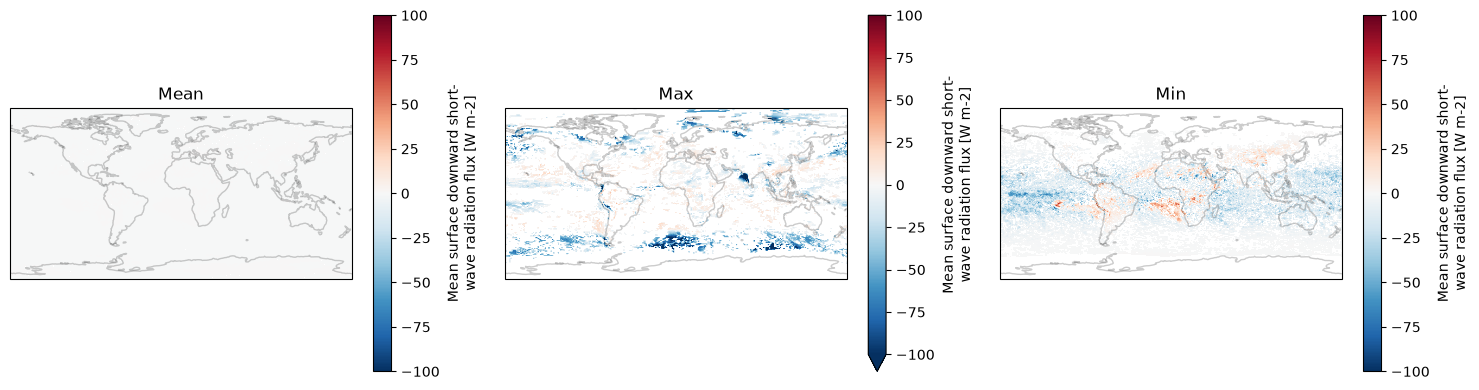

In [30]:
fig, axes = plt.subplots(
    ncols=3,
    figsize=(15, 4),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

ax = axes[0]
delta = output_fut_603_avg - output_fut_ref_avg
delta.where(np.abs(delta) > 0).plot(ax=ax, vmax=100, transform=ccrs.PlateCarree())
ax.coastlines(color="k", alpha=0.2)
ax.set_title("Mean")

ax = axes[1]
delta = output_fut_603_max - output_fut_ref_max
delta.where(np.abs(delta) > 0).plot(ax=ax, vmax=100, transform=ccrs.PlateCarree())
ax.coastlines(color="k", alpha=0.2)
ax.set_title("Max")

ax = axes[2]
delta = output_fut_603_min - output_fut_ref_min
delta.where(np.abs(delta) > 0).plot(ax=ax, vmax=100, transform=ccrs.PlateCarree())
ax.coastlines(color="k", alpha=0.2)
ax.set_title("Min")

plt.tight_layout()

In [ ]:
fig, axes = plt.subplots(
    ncols=4,
    figsize=(18, 4),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

ax = axes[0]
delta_603 = output_fut_603_avg - output_hist_603_avg
delta_603.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.PuOr_r, vmax=15)
ax.coastlines(color="k", alpha=0.2)
ax.set_title("PR603 (SSP245-Hist)")

ax = axes[1]
delta_ref = output_fut_ref_avg - output_hist_ref_avg
delta_ref.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.PuOr_r, vmax=15)
ax.coastlines(color="k", alpha=0.2)
ax.set_title("Ref (SSP245-Hist)")

ax = axes[2]
delta_delta = delta_603 - delta_ref
delta_delta.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.PuOr_r, vmax=15)
ax.coastlines(color="k", alpha=0.2)
ax.set_title("PR603 Delta - Ref Delta")

ax = axes[3]
delta_delta = delta_603 - delta_ref
delta_delta.plot(ax=ax, transform=ccrs.PlateCarree(), vmax=0.2, cmap=plt.cm.PuOr_r)
ax.coastlines(color="k", alpha=0.2)
ax.set_title("PR603 Delta - Ref Delta (diff colorbar)")

plt.tight_layout()

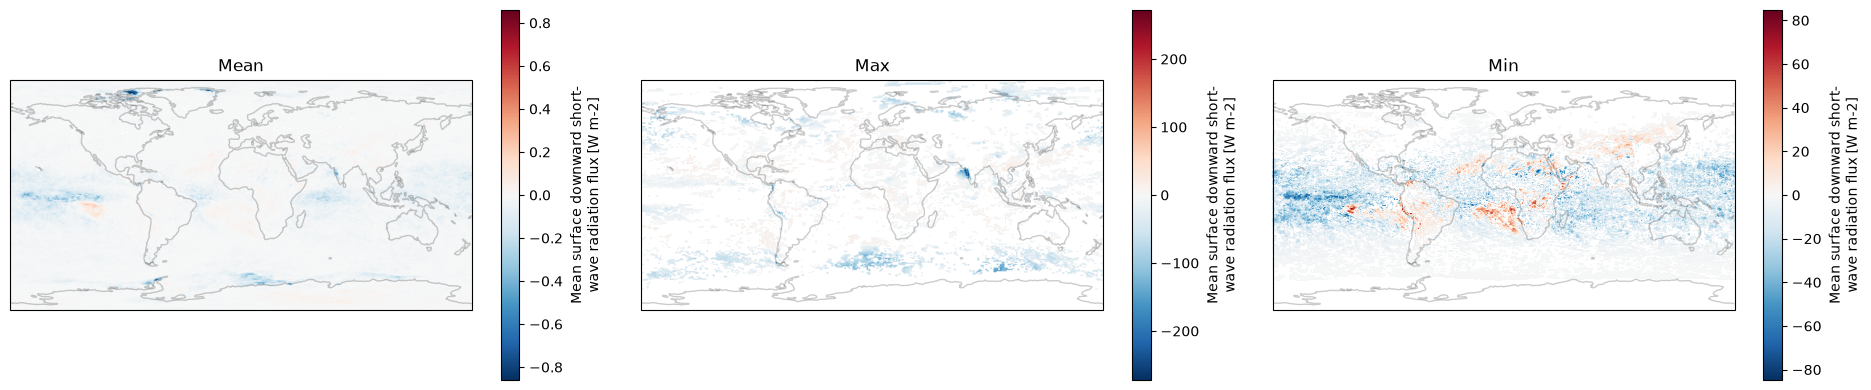

In [31]:
fig, axes = plt.subplots(
    ncols=3,
    figsize=(19, 4),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

ax = axes[0]
delta = output_fut_603_avg - output_fut_ref_avg
delta.where(np.abs(delta) > 0).plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines(color="k", alpha=0.2)
ax.set_title("Mean")

ax = axes[1]
delta = output_fut_603_max - output_fut_ref_max
delta.where(np.abs(delta) > 0).plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines(color="k", alpha=0.2)
ax.set_title("Max")

ax = axes[2]
delta = output_fut_603_min - output_fut_ref_min
delta.where(np.abs(delta) > 0).plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines(color="k", alpha=0.2)
ax.set_title("Min")

plt.tight_layout()

# Evaluate rsds flags

In [7]:
from srm.qa_flags import DIR_QA_FLAG_CONSTANT_INPUTS, flag_rsds_above_max

In [8]:
def load_rsds_lims(
    key: str = "zonal_doy_max_rsds",
    fpath: str = DIR_QA_FLAG_CONSTANT_INPUTS + "zonal_doy_max_rsds.zarr",
) -> xr.DataArray:
    return xr.open_zarr(fpath, group=key)["data"].load()

In [9]:
zonal_doy_max_rsds = load_rsds_lims()

In [10]:
rsds_flag_fut_603 = (
    flag_rsds_above_max(da=output_fut_603, zonal_doy_max_rsds=zonal_doy_max_rsds)
    .sum(dim="time")
    .compute()
)

In [17]:
rsds_flag_fut_603 = rsds_flag_fut_603.sum(dim="time").compute()  # .plot()

In [14]:
rsds_flag_fut_ref = (
    flag_rsds_above_max(da=output_fut_ref, zonal_doy_max_rsds=zonal_doy_max_rsds)
    .sum(dim="time")
    .compute()
)

In [15]:
rsds_flag_hist_603 = (
    flag_rsds_above_max(da=output_hist_603, zonal_doy_max_rsds=zonal_doy_max_rsds)
    .sum(dim="time")
    .compute()
)

In [16]:
rsds_flag_hist_ref = (
    flag_rsds_above_max(da=output_hist_ref, zonal_doy_max_rsds=zonal_doy_max_rsds)
    .sum(dim="time")
    .compute()
)

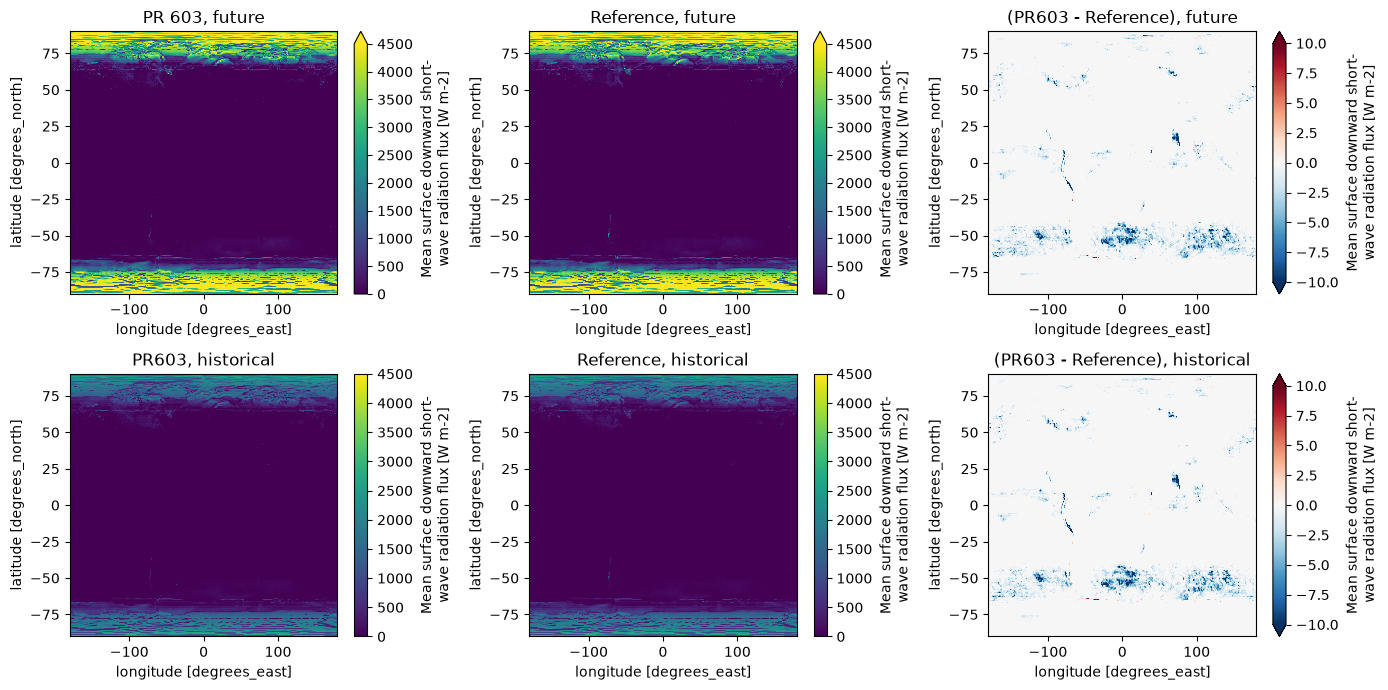

In [25]:
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(14, 7))
ax = axes[0, 0]
rsds_flag_fut_603.plot(ax=ax, vmax=4500)
ax.set_title("PR 603, future")

ax = axes[0, 1]
rsds_flag_fut_ref.plot(ax=ax, vmax=4500)
ax.set_title("Reference, future")

ax = axes[0, 2]
(rsds_flag_fut_603 - rsds_flag_fut_ref).plot(ax=ax, vmax=10)
ax.set_title("(PR603 - Reference), future")

ax = axes[1, 0]
rsds_flag_hist_603.plot(ax=ax, vmax=4500)
ax.set_title("PR603, historical")

ax = axes[1, 1]
rsds_flag_hist_ref.plot(ax=ax, vmax=4500)
ax.set_title("Reference, historical")

ax = axes[1, 2]
(rsds_flag_fut_603 - rsds_flag_fut_ref).plot(ax=ax, vmax=10)
ax.set_title("(PR603 - Reference), historical")

plt.tight_layout()